<a href="https://colab.research.google.com/github/fatm-a1/Arabic-Sentiment-Analysis/blob/main/ARABIC_SENTIMENT_ANALYSIS_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ARABIC SENTIMENT ANALYSIS PROJECT**


# *LABR DATASET*
# MACHINE LEARNING + CNN + STREAMLIT SUPPORT

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from datasets import load_dataset

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud

# **LOAD DATASET**

In [ ]:
dataset = load_dataset("mohamedadaly/labr")

df = pd.DataFrame(dataset['train'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/3.83M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/919k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11760 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2935 [00:00<?, ? examples/s]

# **DISPLAY DATASET**

In [ ]:
# =========================================================
# PROFESSIONAL DATASET DISPLAY
# =========================================================

from IPython.display import display, HTML

# Dataset title
print("=" * 60)
print("           LABR DATASET OVERVIEW")
print("=" * 60)

# Shape
print(f"\nDataset Shape: {df.shape}")

# Columns
print("\nColumns Names:")

for col in df.columns:
    print(f"✔ {col}")

# Missing values
print("\nMissing Values:")

print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")

print(df.duplicated().sum())

print("\n" + "=" * 60)

# Display first rows professionally
print("\nFirst 5 Rows:\n")

display(df.head())

print("\n" + "=" * 60)


           LABR DATASET OVERVIEW

Dataset Shape: (11760, 2)

Columns Names:
✔ text
✔ label

Missing Values:
text     0
label    0
dtype: int64

Duplicate Rows:
196


First 5 Rows:



,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,0
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,0
3,خيالية جدًا . ماحبيتها الصراحة,0
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",0


# **DATASET INFORMATION**

In [ ]:


print("=" * 60)
print("           DATASET INFORMATION")
print("=" * 60)

print(f"\nTotal Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

print("\nColumns and Data Types:\n")

info_df = pd.DataFrame({

    'Column Name': df.columns,

    'Data Type': df.dtypes.values,

    'Non-Null Count': df.notnull().sum().values
})

display(info_df)

print("\nMissing Values:\n")

missing_df = pd.DataFrame(

    df.isnull().sum(),

    columns=['Missing Values']
)

display(missing_df)

duplicates = df.duplicated().sum()

print(f"\nDuplicate Rows Found: {duplicates}")

print("\n" + "=" * 60)

           DATASET INFORMATION

Total Rows    : 11760
Total Columns : 2

Columns and Data Types:



,Column Name,Data Type,Non-Null Count
0,text,object,11760
1,label,int64,11760



Missing Values:



,Missing Values
text,0
label,0



Duplicate Rows Found: 196



# **ORIGINAL LABEL DISTRIBUTION**

         ORIGINAL LABEL DISTRIBUTION


,Label,Count
0,0,2352
1,1,2352
2,2,2352
3,3,2352
4,4,2352


/tmp/ipykernel_25286/3925171241.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


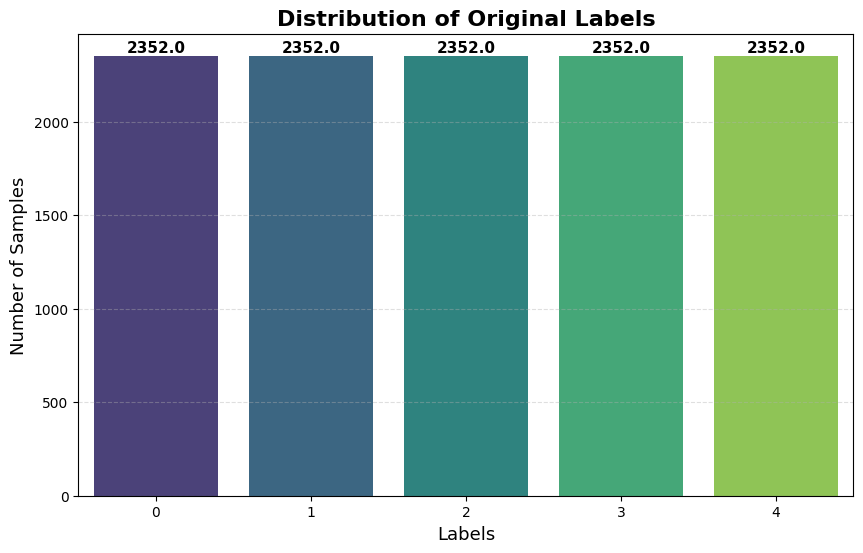

In [ ]:

print("=" * 60)
print("         ORIGINAL LABEL DISTRIBUTION")
print("=" * 60)

label_counts = df['label'].value_counts().sort_index()

labels_df = pd.DataFrame({

    'Label': label_counts.index,

    'Count': label_counts.values
})

display(labels_df)


plt.figure(figsize=(10,6))

ax = sns.countplot(

    x='label',

    data=df,

    palette='viridis'
)

for p in ax.patches:

    ax.annotate(

        f'{p.get_height()}',

        (p.get_x() + p.get_width() / 2., p.get_height()),

        ha='center',

        va='bottom',

        fontsize=11,

        fontweight='bold'
    )

plt.title(

    "Distribution of Original Labels",

    fontsize=16,

    fontweight='bold'
)

plt.xlabel(

    "Labels",

    fontsize=13
)

plt.ylabel(

    "Number of Samples",

    fontsize=13
)

plt.grid(

    axis='y',

    linestyle='--',

    alpha=0.4
)

plt.show()

print("\n" + "=" * 60)

# **CONVERT LABELS TO POSITIVE / NEGATIVE**

In [ ]:
def convert_label(x):

    if x >= 3:
        return "Positive"

    else:
        return "Negative"

df['sentiment'] = df['label'].apply(convert_label)

print("\nSentiment Distribution:\n")

print(df['sentiment'].value_counts())


Sentiment Distribution:

sentiment
Negative    7056
Positive    4704
Name: count, dtype: int64


# **TEXT CLEANING FUNCTION**

In [ ]:
def clean_text(text):

    text = str(text)

    text = re.sub(r'http\S+', ' ', text)

    text = re.sub(r'[0-9٠-٩]', ' ', text)

    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)

    text = re.sub("[إأآا]", "ا", text)

    text = re.sub("ى", "ي", text)

    text = re.sub("ؤ", "و", text)

    text = re.sub("ئ", "ي", text)

    text = re.sub("ة", "ه", text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


# **APPLY CLEANING**

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

print("\nCleaned Text Sample:\n")

display(df[['text', 'clean_text']].head(10))



Cleaned Text Sample:



,text,clean_text
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,هي روايه ممله لابعد الحدود مفيهاش اي حاجه تشد ...
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,بدات قِراءه الصفحات الاولي علي نغمات فيفالدي ،...
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,اول مره اكتب انطباعي عن كتاب قبل ان انتهي حتي ...
3,خيالية جدًا . ماحبيتها الصراحة,خياليه جدًا ماحبيتها الصراحه
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",ولاني ما اتقن قراءه ما بين السطور ما استسغتها ...
5,أحببت أسلوب الكتابة لا أكثر. بقيت أنتظر الأحد...,احببت اسلوب الكتابه لا اكثر بقيت انتظر الاحداث...
6,توقفت عن قراءته ، لعدة اسباب. لم يعجبني الكتا...,توقفت عن قراءته ، لعده اسباب لم يعجبني الكتاب ...
7,مراجعاتي دوما طوييييلة وهالمره مختصر مفيد خسا...,مراجعاتي دوما طوييييله وهالمره مختصر مفيد خسار...
8,أسوأ ما قرأت ليوسف زيدان أيضا عرفت النهاية من...,اسوا ما قرات ليوسف زيدان ايضا عرفت النهايه من ...
9,ممله بعض الشئ و نهاية دارمية بحته,ممله بعض الشي و نهايه دارميه بحته


# **TEXT LENGTH ANALYSIS**

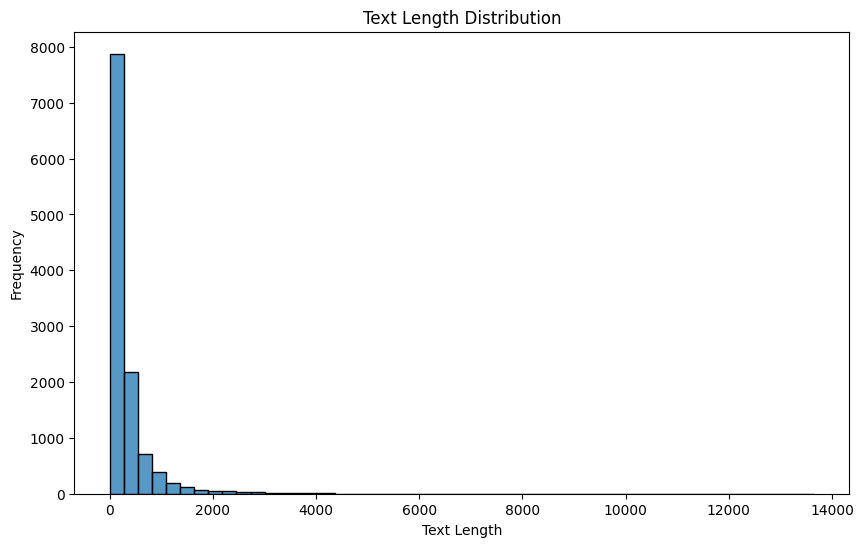

In [ ]:
df['text_length'] = df['clean_text'].apply(len)

plt.figure(figsize=(10,6))

sns.histplot(df['text_length'], bins=50)

plt.title("Text Length Distribution")

plt.xlabel("Text Length")

plt.ylabel("Frequency")

plt.show()

# **WORD CLOUD**

                ARABIC WORD CLOUD

Sample from Cleaned Text:

هي روايه ممله لابعد الحدود مفيهاش اي حاجه تشد الا انها صغيره مفيهاش جديد يعني ولا في القصه ولا في الاسلوب ولا اي حاجه واحده بترفض مغريات الرشوه رغم حاجتها للفلوس كذا مره و تدي درس لزمايلها عن رفضها و انها هاتفضل نضيفه و بموقف ساذج اوي تقتنع و تقبل و مش بس تقبل لا بتتخلي عن مباديها كلها بمبدا خربانه خربانه مثلا في اول الروايه قعد يذكر ان المصلحه كلها رجاله و مفيهاش اي ستات و دي اول دفعه من الستات تشتغل فيها حاجه ملهاش اي لازمه انها تتذكر اعتقد كمان الاسماء متلغبطه كل شويه اسم من الشخصيات يتغير بد


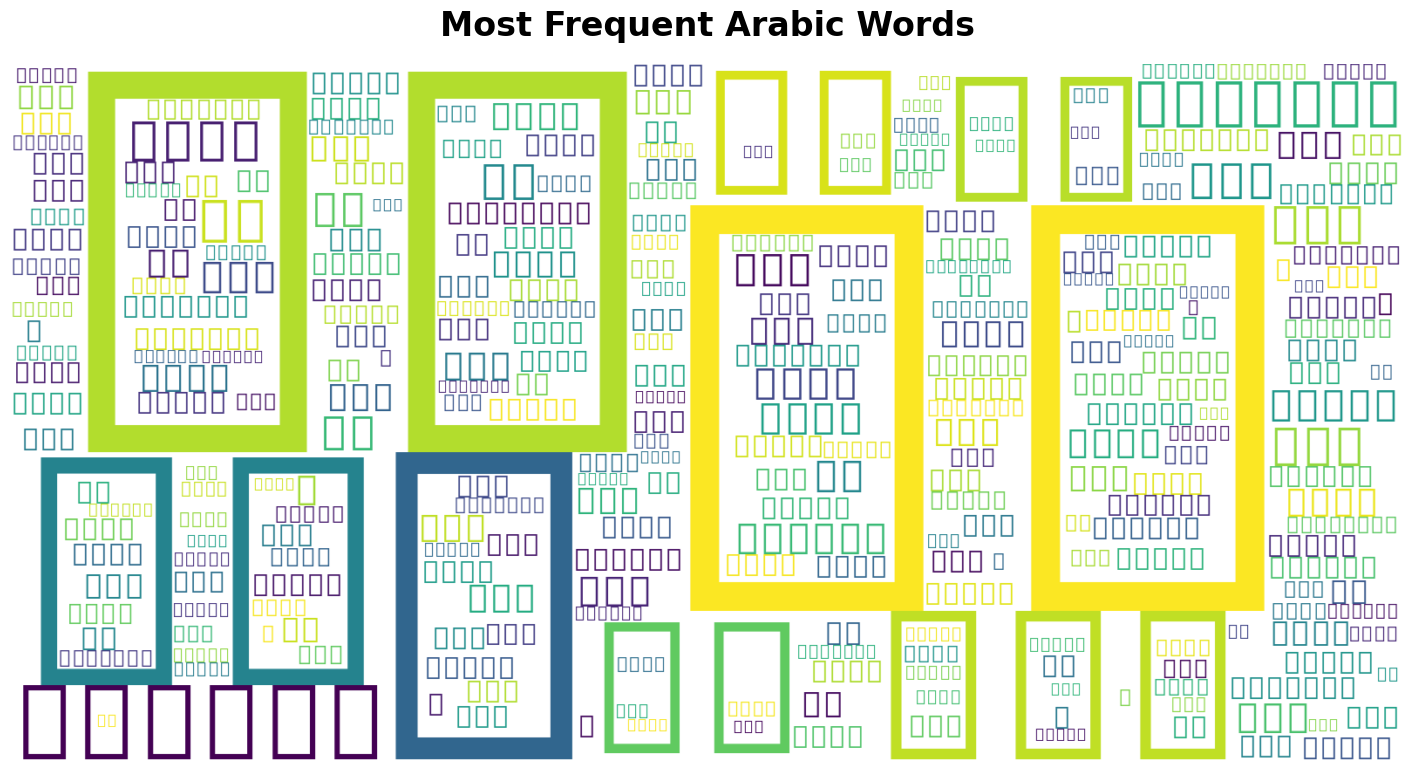

In [ ]:


print("=" * 70)
print("                ARABIC WORD CLOUD")
print("=" * 70)

all_words = " ".join(

    df['clean_text']

    .dropna()

    .astype(str)

    .tolist()
)

print("\nSample from Cleaned Text:\n")

print(all_words[:500])


wordcloud = WordCloud(

    width=1600,

    height=800,

    background_color='white',

    collocations=False,

    max_words=300,

    prefer_horizontal=1.0,

    min_font_size=10

).generate(all_words)


plt.figure(figsize=(18,10))

plt.imshow(

    wordcloud,

    interpolation='bilinear'
)

plt.axis('off')

plt.title(

    "Most Frequent Arabic Words",

    fontsize=24,

    fontweight='bold',

    pad=20
)

plt.box(False)

plt.show()

print("\n" + "=" * 70)

# **FEATURE EXTRACTION USING TF-IDF**

In [ ]:
vectorizer = TfidfVectorizer(

    max_features=30000,

    ngram_range=(1,3),

    min_df=2,

    max_df=0.9,

    sublinear_tf=True
)

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment']

# **TRAIN TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# **MACHINE LEARNING MODEL**

In [ ]:
model = LogisticRegression(

    max_iter=3000,

    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000)

# **PREDICTIONS**

In [ ]:
y_pred = model.predict(X_test)

# **EVALUATION**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nMachine Learning Accuracy:\n")

print(accuracy)


Machine Learning Accuracy:

0.7614795918367347


# **CLASSIFICATION REPORT**

In [ ]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80      1411
    Positive       0.69      0.73      0.71       941

    accuracy                           0.76      2352
   macro avg       0.75      0.76      0.75      2352
weighted avg       0.76      0.76      0.76      2352



# **CONFUSION MATRIX**

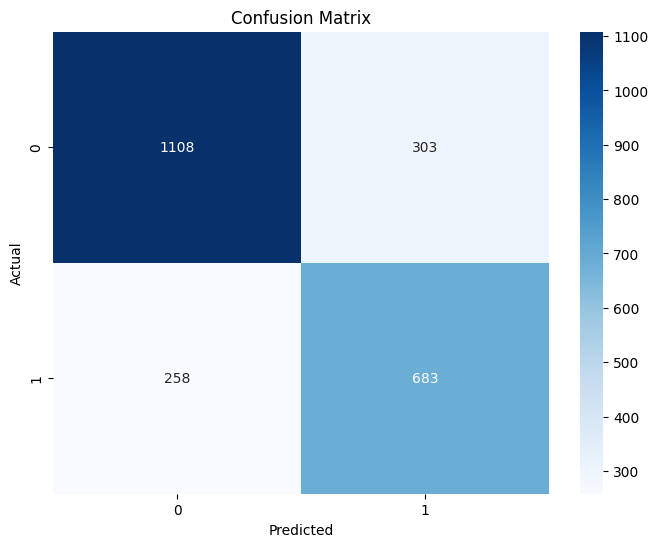

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **SAVE MODEL AND VECTORIZER**

In [ ]:
pickle.dump(model, open('model.pkl', 'wb'))

pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

print("\nModel Saved Successfully")


Model Saved Successfully


# **TEST ON NEW SENTENCES**

In [ ]:
samples = [

    "هذا الكتاب رائع جدا",

    "الخدمة سيئة للغاية",

    "احببت هذا التطبيق كثيرا",

    "لم يعجبني الفيلم ابدا"
]

samples_clean = [clean_text(text) for text in samples]

samples_vectors = vectorizer.transform(samples_clean)

predictions = model.predict(samples_vectors)

print("\nPredictions:\n")

for text, prediction in zip(samples, predictions):

    print("Sentence:", text)

    print("Prediction:", prediction)

    print("-" * 50)


Predictions:

Sentence: هذا الكتاب رائع جدا
Prediction: Positive
--------------------------------------------------
Sentence: الخدمة سيئة للغاية
Prediction: Negative
--------------------------------------------------
Sentence: احببت هذا التطبيق كثيرا
Prediction: Positive
--------------------------------------------------
Sentence: لم يعجبني الفيلم ابدا
Prediction: Negative
--------------------------------------------------


# **CNN MODEL**

In [ ]:
print("\nStarting CNN Model...\n")

# Encode labels

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['sentiment'])

# Tokenizer

tokenizer = Tokenizer(num_words=30000)

tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences

sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Padding

max_length = 200

X_pad = pad_sequences(

    sequences,

    maxlen=max_length,

    padding='post'
)



Starting CNN Model...



# **CNN TRAIN TEST SPLIT**

In [ ]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(

    X_pad,

    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)


# **BUILD CNN MODEL**

In [ ]:

cnn_model = Sequential()

cnn_model.add(

    Embedding(

        input_dim=30000,

        output_dim=128,

        input_length=max_length
    )
)

cnn_model.add(

    Conv1D(

        filters=128,

        kernel_size=5,

        activation='relu'
    )
)

cnn_model.add(GlobalMaxPooling1D())

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(64, activation='relu'))

cnn_model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# **COMPILE CNN MODEL**

In [ ]:


cnn_model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)



cnn_model.build(input_shape=(None, max_length))



print("\n")
print("=" * 70)
print("                CNN MODEL SUMMARY")
print("=" * 70)

cnn_model.summary()

print("=" * 70)



                CNN MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930,369 (14.99 MB)

 Trainable params: 3,930,369 (14.99 MB)

 Non-trainable params: 0 (0.00 B)

# **TRAIN CNN MODEL**

In [ ]:
history = cnn_model.fit(

    X_train_cnn,

    y_train_cnn,

    epochs=5,

    batch_size=64,

    validation_split=0.1
)

Epoch 1/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step - accuracy: 0.7703 - loss: 0.4848 - val_accuracy: 0.7386 - val_loss: 0.5276
Epoch 2/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.9166 - loss: 0.2251 - val_accuracy: 0.7205 - val_loss: 0.6563
Epoch 3/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.9708 - loss: 0.0875 - val_accuracy: 0.7194 - val_loss: 0.8394
Epoch 4/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step - accuracy: 0.9855 - loss: 0.0435 - val_accuracy: 0.7311 - val_loss: 0.9732
Epoch 5/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 41s 199ms/step - accuracy: 0.9891 - loss: 0.0288 - val_accuracy: 0.7184 - val_loss: 1.1127


# **CNN EVALUATION**

In [ ]:
loss, cnn_accuracy = cnn_model.evaluate(

    X_test_cnn,

    y_test_cnn
)

print("\nCNN Accuracy:\n")

print(cnn_accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7292 - loss: 1.1213

CNN Accuracy:

0.7291666865348816


# **CONFUSION MATRIX**

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


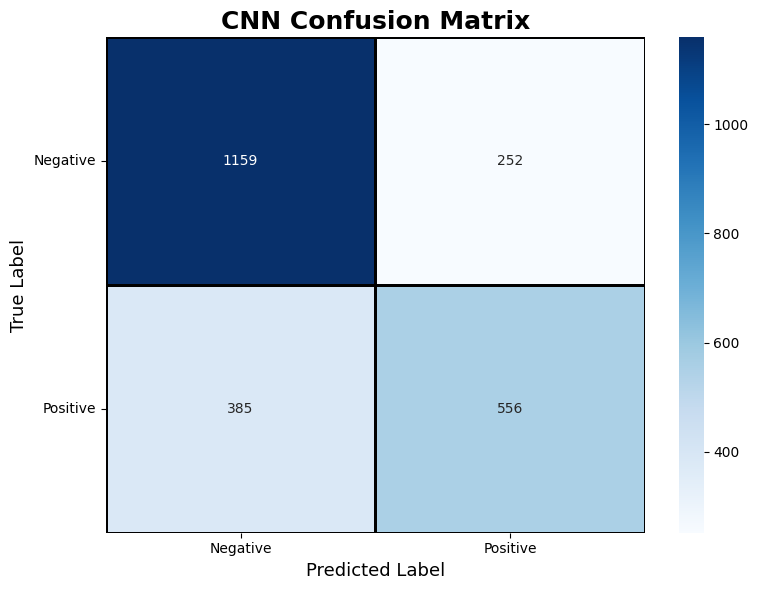

In [ ]:


from sklearn.metrics import confusion_matrix

cnn_pred_probs = cnn_model.predict(X_test_cnn)


cnn_pred_classes = (

    cnn_pred_probs > 0.5

).astype(int)

cnn_cm = confusion_matrix(

    y_test_cnn,

    cnn_pred_classes
)


plt.figure(figsize=(8,6))

sns.heatmap(

    cnn_cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    linewidths=1,

    linecolor='black'
)

plt.title(

    "CNN Confusion Matrix",

    fontsize=18,

    fontweight='bold'
)

plt.xlabel(

    "Predicted Label",

    fontsize=13
)

plt.ylabel(

    "True Label",

    fontsize=13
)

plt.xticks(

    [0.5, 1.5],

    ['Negative', 'Positive']
)

plt.yticks(

    [0.5, 1.5],

    ['Negative', 'Positive'],

    rotation=0
)

plt.tight_layout()

plt.show()

# **PLOT CNN ACCURACY**

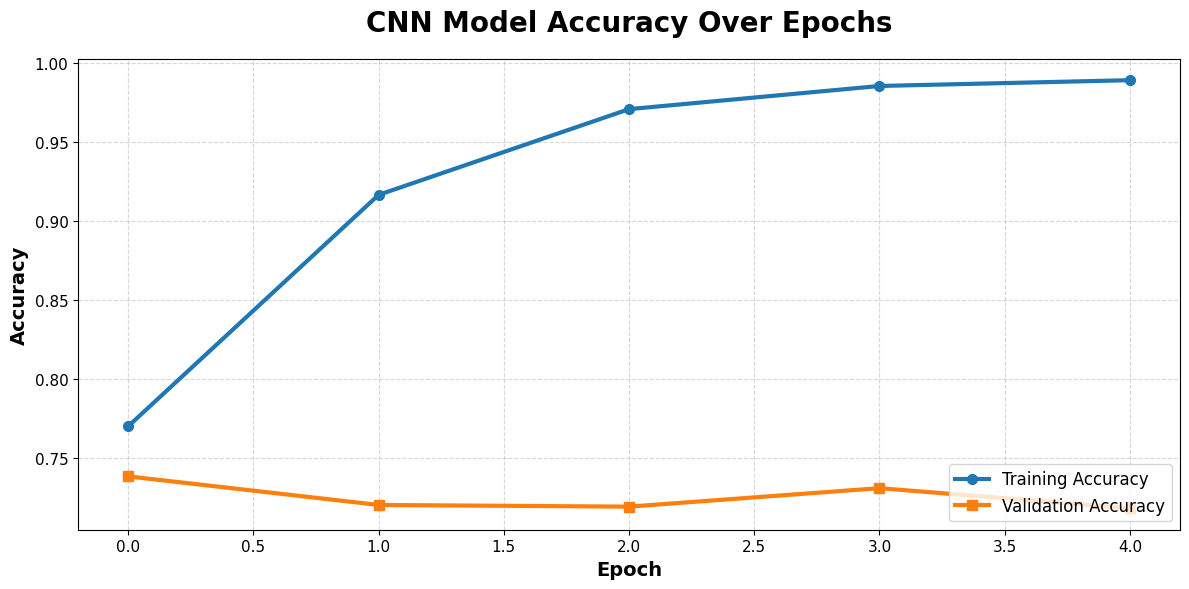

In [ ]:


plt.figure(figsize=(12,6))

plt.plot(

    history.history['accuracy'],

    linewidth=3,

    marker='o',

    markersize=7,

    label='Training Accuracy'
)


plt.plot(

    history.history['val_accuracy'],

    linewidth=3,

    marker='s',

    markersize=7,

    label='Validation Accuracy'
)


plt.title(

    "CNN Model Accuracy Over Epochs",

    fontsize=20,

    fontweight='bold',

    pad=20
)

plt.xlabel(

    "Epoch",

    fontsize=14,

    fontweight='bold'
)

plt.ylabel(

    "Accuracy",

    fontsize=14,

    fontweight='bold'
)



plt.grid(

    True,

    linestyle='--',

    alpha=0.5
)


plt.legend(

    fontsize=12,

    loc='lower right'
)



plt.xticks(fontsize=11)

plt.yticks(fontsize=11)

plt.tight_layout()

plt.show()

# **TEST CNN MODEL ON NEW SENTENCES**

In [ ]:


print("\n")
print("=" * 70)
print("            CNN MODEL PREDICTIONS")
print("=" * 70)

cnn_samples = [

    "هذا الكتاب رائع جدا",

    "الخدمة سيئة للغاية",

    "احببت هذا التطبيق كثيرا",

    "الفيلم كان ممل جدا",

    "التجربة كانت ممتازة",

    "لم يعجبني هذا المنتج ابدا"
]

# =========================================================
# CLEAN TEXT
# =========================================================

cnn_samples_clean = [

    clean_text(text)

    for text in cnn_samples
]

# =========================================================
# CONVERT TEXT TO SEQUENCES
# =========================================================

cnn_sequences = tokenizer.texts_to_sequences(

    cnn_samples_clean
)

# =========================================================
# PADDING
# =========================================================

cnn_padded = pad_sequences(

    cnn_sequences,

    maxlen=max_length,

    padding='post'
)

# =========================================================
# PREDICTIONS
# =========================================================

cnn_predictions = cnn_model.predict(cnn_padded)

# =========================================================
# DISPLAY RESULTS
# =========================================================

for text, prediction in zip(cnn_samples, cnn_predictions):

    predicted_label = "Positive" if prediction[0] > 0.5 else "Negative"

    confidence = prediction[0]

    print("\n" + "-" * 70)

    print(f"Sentence   : {text}")

    print(f"Prediction : {predicted_label}")

    print(f"Confidence : {confidence:.4f}")

print("\n" + "=" * 70)



            CNN MODEL PREDICTIONS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

----------------------------------------------------------------------
Sentence   : هذا الكتاب رائع جدا
Prediction : Positive
Confidence : 0.9991

----------------------------------------------------------------------
Sentence   : الخدمة سيئة للغاية
Prediction : Negative
Confidence : 0.0000

----------------------------------------------------------------------
Sentence   : احببت هذا التطبيق كثيرا
Prediction : Positive
Confidence : 0.9325

----------------------------------------------------------------------
Sentence   : الفيلم كان ممل جدا
Prediction : Negative
Confidence : 0.0001

----------------------------------------------------------------------
Sentence   : التجربة كانت ممتازة
Prediction : Negative
Confidence : 0.1854

----------------------------------------------------------------------
Sentence   : لم يعجبني هذا المنتج ابدا
Prediction : Negative
Confidence : 0.0007



# **FINAL MESSAGE**

In [ ]:
# =========================================================
# FINAL PROJECT SUMMARY
# =========================================================

print("\n")

print("╔" + "═" * 70 + "╗")

print("║{:^70}║".format(
    "ARABIC SENTIMENT ANALYSIS PROJECT COMPLETED"
))

print("╠" + "═" * 70 + "╣")

print("║ {:<68}║".format(
    "Dataset Used : LABR Arabic Dataset"
))

print("║ {:<68}║".format(
    "Project Type : Natural Language Processing (NLP)"
))

print("║ {:<68}║".format(
    "Language     : Arabic"
))

print("╠" + "═" * 70 + "╣")

print("║ {:<68}║".format(
    "Techniques and Models Used:"
))

print("║ {:<68}║".format(
    "1. Arabic Text Cleaning"
))

print("║ {:<68}║".format(
    "2. TF-IDF Feature Extraction"
))

print("║ {:<68}║".format(
    "3. Logistic Regression Model"
))

print("║ {:<68}║".format(
    "4. CNN Deep Learning Model"
))

print("║ {:<68}║".format(
    "5. WordCloud Visualization"
))

print("║ {:<68}║".format(
    "6. Confusion Matrix"
))

print("║ {:<68}║".format(
    "7. Classification Report"
))

print("╠" + "═" * 70 + "╣")

print("║ {:<68}║".format(
    f"Machine Learning Accuracy : {accuracy:.4f}"
))

print("║ {:<68}║".format(
    f"CNN Model Accuracy        : {cnn_accuracy:.4f}"
))

print("╠" + "═" * 70 + "╣")

print("║ {:<68}║".format(
    "Generated Files:"
))

print("║ {:<68}║".format(
    "- model.pkl"
))

print("║ {:<68}║".format(
    "- vectorizer.pkl"
))

print("╠" + "═" * 70 + "╣")

print("║{:^70}║".format(
    "PROJECT EXECUTED SUCCESSFULLY"
))

print("╚" + "═" * 70 + "╝")



╔══════════════════════════════════════════════════════════════════════╗
║             ARABIC SENTIMENT ANALYSIS PROJECT COMPLETED              ║
╠══════════════════════════════════════════════════════════════════════╣
║ Dataset Used : LABR Arabic Dataset                                  ║
║ Project Type : Natural Language Processing (NLP)                    ║
║ Language     : Arabic                                               ║
╠══════════════════════════════════════════════════════════════════════╣
║ Techniques and Models Used:                                         ║
║ 1. Arabic Text Cleaning                                             ║
║ 2. TF-IDF Feature Extraction                                        ║
║ 3. Logistic Regression Model                                        ║
║ 4. CNN Deep Learning Model                                          ║
║ 5. WordCloud Visualization                                          ║
║ 6. Confusion Matrix                                     